In [2]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

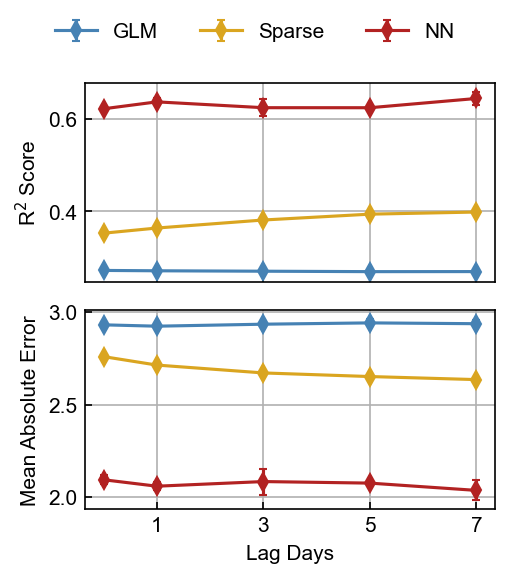

In [7]:
from sklearn.metrics import r2_score, mean_absolute_error
from airquality.analysis.postprocessing import aggregate_n_params, aggregate_predictions
from airquality.analysis.plotting import plot_aggregate_predictions

info = {
    'GLM': {
        'path': 'GLM',
        'name': 'base',
        'color': 'steelblue',
    },
    'Sparse': {
        'path': 'GLM',
        'name': 'stlsq',
        'color': 'goldenrod',
    },
    'NN': {
        'path': 'FCNN',
        'color': 'firebrick',

    }
}

score_funcs = {
    'R2': r2_score,
    'MAE': mean_absolute_error,
}

def accuracy_lag_figure(info, socio_var):
    fig, ax = plt.subplots(2, 1, figsize=(3.5, 3.5), dpi=150, sharex=True)

    all_df = []

    for key, params in info.items():
        lag_df = pd.DataFrame()
        for root, folders, files in os.walk(os.path.join(os.environ['MODELS_DIR'], socio_var, params['path'])):
            if key == 'NN':
                if not 'lag' in os.path.basename(root):
                    continue

                lag = int(root.split('/')[-1].strip('lag'))
            else:
                if not os.path.basename(root) == params['name']:
                    continue

                if not 'lag' in root.split('/')[-2]:
                    continue

                lag = int(root.split('/')[-2].strip('lag'))

            # Go through and get the aggregate predictions and accuracy for that lag
            trial_predictions = aggregate_predictions(root, overwrite=True, csv_kwargs={})
            for name, func in score_funcs.items():
                scores = trial_predictions.groupby('trial_index').apply(lambda group : func(group['Observed'], group['Predicted']), include_groups=False)
                scores = pd.DataFrame({'score': scores.values}, index=scores.index)
                lag_df.loc[lag, name+'_mean'] = scores['score'].mean()
                lag_df.loc[lag, name+'_std'] = scores['score'].std()

        lag_df = lag_df.sort_index()
        for ii, name in enumerate(score_funcs.keys()):
            ax[ii].errorbar(
                x=lag_df.index, 
                y=lag_df[name+'_mean'], 
                yerr=lag_df[name+'_std'],
                capsize=2,
                marker='d',
                color=params['color'], 
                label=key)

        all_df.append(lag_df.assign(model=key))
    
    ax[0].set(ylabel='R$^2$ Score')
    ax[1].set(ylabel='Mean Absolute Error', xlabel='Lag Days', xticks=[1, 3, 5, 7])
    fig.legend(
        *ax[0].get_legend_handles_labels(),
        loc='lower center', bbox_to_anchor=[0.5, 1],
        ncol=3,
    )

    return pd.concat(all_df)

score_df = accuracy_lag_figure(info, 'coi')
plt.tight_layout()
plt.savefig(f"{os.environ['MODELS_DIR']}/coi/lag_accuracy.pdf")

In [11]:
score_df.index.names = ['lag_days']
score_df['R2'] = score_df.apply(lambda row: f"{row['R2_mean']:.3f} ({row['R2_std']:.3f})", axis=1)
score_df['MAE'] = score_df.apply(lambda row: f"{row['MAE_mean']:.3f} ({row['MAE_std']:.3f})", axis=1)

table = score_df.loc[:, ['model', 'R2', 'MAE']].pivot(columns=['model'])
table

R2                                          MAE  \
model               GLM             NN         Sparse            GLM   
lag_days                                                               
0         0.272 (0.002)  0.623 (0.005)  0.353 (0.003)  2.932 (0.015)   
1         0.271 (0.002)  0.638 (0.007)  0.364 (0.004)  2.924 (0.016)   
3         0.270 (0.003)  0.625 (0.019)  0.381 (0.002)  2.935 (0.017)   
5         0.269 (0.003)  0.625 (0.004)  0.394 (0.007)  2.942 (0.019)   
7         0.270 (0.003)  0.645 (0.014)  0.399 (0.004)  2.938 (0.019)   

                                        
model                NN         Sparse  
lag_days                                
0         2.095 (0.023)  2.760 (0.009)  
1         2.060 (0.021)  2.714 (0.010)  
3         2.085 (0.070)  2.672 (0.008)  
5         2.077 (0.005)  2.652 (0.015)  
7         2.038 (0.054)  2.636 (0.007)

In [12]:
table = table.swaplevel(0, 1, axis=1).loc[:, 'NN']
print(table.to_latex())
table

\begin{tabular}{lll}
\toprule
 & R2 & MAE \\
lag_days &  &  \\
\midrule
0 & 0.623 (0.005) & 2.095 (0.023) \\
1 & 0.638 (0.007) & 2.060 (0.021) \\
3 & 0.625 (0.019) & 2.085 (0.070) \\
5 & 0.625 (0.004) & 2.077 (0.005) \\
7 & 0.645 (0.014) & 2.038 (0.054) \\
\bottomrule
\end{tabular}



,R2,MAE
lag_days,,
0,0.623 (0.005),2.095 (0.023)
1,0.638 (0.007),2.060 (0.021)
3,0.625 (0.019),2.085 (0.070)
5,0.625 (0.004),2.077 (0.005)
7,0.645 (0.014),2.038 (0.054)
